**Project Overview:** EOR Comparative Performance Simulator

The project models secondary and tertiary recovery mechanisms using:

1.   Fractional Flow Theory (Buckley-Leverett): For baseline waterflooding and polymer flooding (altering water viscosity and mobility ratio $M$).
2.   Kovall / Empirical Recovery Curves: For $\text{CO}_2$ miscible displacement (accounting for minimum miscibility pressure and sweep efficiency).
3.   Economic & Technical Metrics: Computes cumulative recovery factor ($RF$), incremental oil produced, and Net Present Value (NPV).





RESERVOIR OOIP: 32.77 MMSTB
                       Metric Waterflooding Polymer Flooding Miscible CO2 Injection
    Final Recovery Factor (%)        42.55%           59.53%                 75.27%
Cumulative Production (MMSTB)         13.94            19.51                  24.66
Incremental Oil vs WF (MMSTB)   0.00 (Base)             5.56                  10.72
    Gross Revenue ($ Million)     $1045.82M        $1463.06M              $1849.87M
Estimated EOR Capex/Opex ($M)       $30.00M          $55.00M                $85.00M
 Net Economic Gain vs WF ($M)        $0.00M         $392.24M               $749.05M


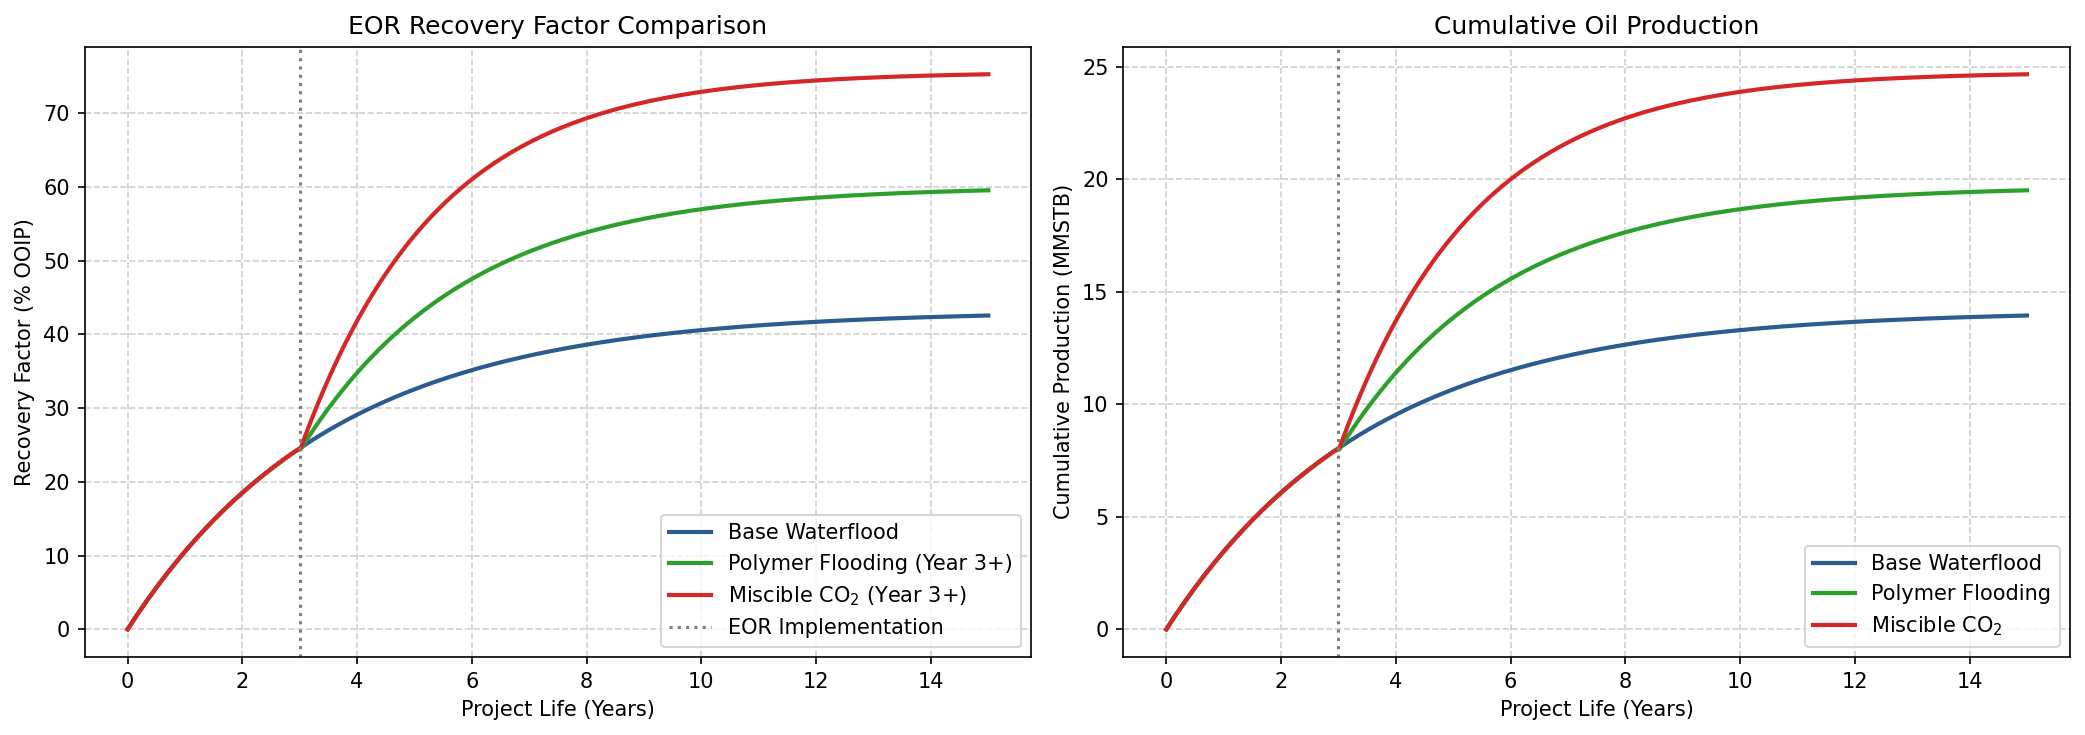

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. RESERVOIR & FLUID DATA INITIALIZATION

class Reservoir:
    def __init__(self):
        # Volumetrics & Rock Properties
        self.area = 640.0             # Area (acres)
        self.thickness = 50.0         # Net pay thickness (ft)
        self.porosity = 0.22          # Porosity (fraction)
        self.initial_sw = 0.25        # Initial water saturation
        self.sor_water = 0.30         # Residual oil saturation to water
        self.sor_polymer = 0.22       # Residual oil saturation to polymer
        self.sor_co2 = 0.12           # Residual oil saturation to CO2
        self.perm = 120.0             # Permeability (mD)

        # Fluid Properties
        self.bo = 1.25                # Oil formation volume factor (RB/STB)
        self.mu_oil = 15.0            # Live oil viscosity (cp)
        self.mu_water = 0.8           # Formation water viscosity (cp)
        self.mu_polymer = 8.0         # Viscosified polymer solution (cp)

        # Original Oil in Place (OOIP in MMSTB)
        # Formula: OOIP (STB) = 7758 * A * h * phi * (1 - Sw) / Bo
        self.ooip_stb = (7758 * self.area * self.thickness * self.porosity * (1 - self.initial_sw)) / self.bo
        self.ooip_mmstb = self.ooip_stb / 1e6


# 2. EOR MECHANISTIC & RECOVERY ENGINE

class EORSimulator:
    def __init__(self, reservoir):
        self.res = reservoir

    def fractional_flow_water(self, sw):
        """Standard Corey-type relative permeability and fractional flow"""
        sw_star = (sw - self.res.initial_sw) / (1 - self.res.initial_sw - self.res.sor_water)
        sw_star = np.clip(sw_star, 0.0, 1.0)

        krw = 0.3 * (sw_star ** 2)
        kro = 0.8 * ((1 - sw_star) ** 2)

        # Mobility Ratio M = (krw/mu_w) / (kro/mu_o)
        fw = 1.0 / (1.0 + (kro / (krw + 1e-6)) * (self.res.mu_water / self.res.mu_oil))
        return np.nan_to_num(fw)

    def simulate_recovery_profiles(self, years=15):
        """Simulates cumulative recovery factor (RF %) over time for 3 scenarios."""
        time = np.linspace(0, years, years * 12) # Monthly time steps

        # 1. Base Case: Waterflooding
        # Governed by adverse mobility ratio (M > 1) causing earlier breakthrough
        rf_max_wf = (1 - self.res.initial_sw - self.res.sor_water) / (1 - self.res.initial_sw) * 0.72
        rf_water = rf_max_wf * (1 - np.exp(-0.28 * time))

        # 2. Chemical EOR: Polymer Flooding (Initiated at year 3)
        # Improves mobility ratio, accelerates sweep efficiency, lowers Sor slightly
        rf_max_poly = (1 - self.res.initial_sw - self.res.sor_polymer) / (1 - self.res.initial_sw) * 0.85
        rf_polymer = np.copy(rf_water)
        for i, t in enumerate(time):
            if t > 3.0:
                t_eor = t - 3.0
                rf_polymer[i] = rf_water[time <= 3.0][-1] + (rf_max_poly - rf_water[time <= 3.0][-1]) * (1 - np.exp(-0.35 * t_eor))

        # 3. Gas EOR: Miscible CO2 Injection (Initiated at year 3)
        # Extreme reduction in Sor, high microscopic displacement efficiency
        rf_max_co2 = (1 - self.res.initial_sw - self.res.sor_co2) / (1 - self.res.initial_sw) * 0.90
        rf_co2 = np.copy(rf_water)
        for i, t in enumerate(time):
            if t > 3.0:
                t_eor = t - 3.0
                rf_co2[i] = rf_water[time <= 3.0][-1] + (rf_max_co2 - rf_water[time <= 3.0][-1]) * (1 - np.exp(-0.42 * t_eor))

        results_df = pd.DataFrame({
            "Time_Years": time,
            "Waterflood_RF": rf_water * 100,
            "Polymer_RF": rf_polymer * 100,
            "CO2_RF": rf_co2 * 100
        })

        # Convert RF to cumulative production (MMSTB)
        results_df["Waterflood_Prod_MMSTB"] = results_df["Waterflood_RF"] * self.res.ooip_mmstb / 100
        results_df["Polymer_Prod_MMSTB"] = results_df["Polymer_RF"] * self.res.ooip_mmstb / 100
        results_df["CO2_Prod_MMSTB"] = results_df["CO2_RF"] * self.res.ooip_mmstb / 100

        return results_df


# 3. ECONOMIC EVALUATION

def evaluate_economics(df, ooip_mmstb, oil_price_usd=75.0, discount_rate=0.10):
    final_wf = df["Waterflood_Prod_MMSTB"].iloc[-1]
    final_poly = df["Polymer_Prod_MMSTB"].iloc[-1]
    final_co2 = df["CO2_Prod_MMSTB"].iloc[-1]

    summary = {
        "Metric": [
            "Final Recovery Factor (%)",
            "Cumulative Production (MMSTB)",
            "Incremental Oil vs WF (MMSTB)",
            "Gross Revenue ($ Million)",
            "Estimated EOR Capex/Opex ($M)",
            "Net Economic Gain vs WF ($M)"
        ],
        "Waterflooding": [
            f"{df['Waterflood_RF'].iloc[-1]:.2f}%",
            f"{final_wf:.2f}",
            "0.00 (Base)",
            f"${final_wf * oil_price_usd:.2f}M",
            "$30.00M",
            "$0.00M"
        ],
        "Polymer Flooding": [
            f"{df['Polymer_RF'].iloc[-1]:.2f}%",
            f"{final_poly:.2f}",
            f"{final_poly - final_wf:.2f}",
            f"${final_poly * oil_price_usd:.2f}M",
            "$55.00M",
            f"${(final_poly - final_wf) * oil_price_usd - 25.0:.2f}M"
        ],
        "Miscible CO2 Injection": [
            f"{df['CO2_RF'].iloc[-1]:.2f}%",
            f"{final_co2:.2f}",
            f"{final_co2 - final_wf:.2f}",
            f"${final_co2 * oil_price_usd:.2f}M",
            "$85.00M",
            f"${(final_co2 - final_wf) * oil_price_usd - 55.0:.2f}M"
        ]
    }
    return pd.DataFrame(summary)

# 4. EXECUTION & PLOTTING

if __name__ == "__main__":
    res = Reservoir()
    sim = EORSimulator(res)
    df_results = sim.simulate_recovery_profiles(years=15)
    econ_table = evaluate_economics(df_results, res.ooip_mmstb)

    print("=" * 60)
    print(f"RESERVOIR OOIP: {res.ooip_mmstb:.2f} MMSTB")
    print("=" * 60)
    print(econ_table.to_string(index=False))

    # Plot Performance Profiles
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

    # Recovery Factor vs Time
    ax1.plot(df_results["Time_Years"], df_results["Waterflood_RF"], label="Base Waterflood", color="#2b5c8f", lw=2)
    ax1.plot(df_results["Time_Years"], df_results["Polymer_RF"], label="Polymer Flooding (Year 3+)", color="#2ca02c", lw=2)
    ax1.plot(df_results["Time_Years"], df_results["CO2_RF"], label=r"Miscible $\mathrm{CO}_2$ (Year 3+)", color="#d62728", lw=2)
    ax1.axvline(x=3.0, color="gray", linestyle=":", label="EOR Implementation")
    ax1.set_xlabel("Project Life (Years)")
    ax1.set_ylabel("Recovery Factor (% OOIP)")
    ax1.set_title("EOR Recovery Factor Comparison")
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend()

    # Cumulative Oil Production
    ax2.plot(df_results["Time_Years"], df_results["Waterflood_Prod_MMSTB"], color="#2b5c8f", lw=2, label="Base Waterflood")
    ax2.plot(df_results["Time_Years"], df_results["Polymer_Prod_MMSTB"], color="#2ca02c", lw=2, label="Polymer Flooding")
    ax2.plot(df_results["Time_Years"], df_results["CO2_Prod_MMSTB"], color="#d62728", lw=2, label=r"Miscible $\mathrm{CO}_2$")
    ax2.axvline(x=3.0, color="gray", linestyle=":")
    ax2.set_xlabel("Project Life (Years)")
    ax2.set_ylabel("Cumulative Production (MMSTB)")
    ax2.set_title("Cumulative Oil Production")
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()